# Week 16: Vision Transformers and Guest Speaker


## Week 16 Lectures

- **Lecture 26:** Vision Transformers
- **Lecture 27:** Guest Speaker


# Lecture 26: Vision Transformers

Vision Transformers represent an image as a sequence of patch tokens. This lecture visualizes patch embeddings, trains a compact ViT from scratch on Imagenette, and fine-tunes a pretrained ViT-B/16.


## Imports and Device

The notebook uses PyTorch for all models. The RLHF section uses a tiny discrete response task so the whole pipeline is visible. The vision section uses `torchvision` datasets, transforms, and pretrained models.

In [1]:
# Core Python utilities
from pathlib import Path
from copy import deepcopy
import math
import random
import shutil
import tarfile
import time
import urllib.request

# Numerical and plotting tools
import numpy as np
import matplotlib.pyplot as plt

# PyTorch and torchvision tools
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import datasets, models
from torchvision.transforms import v2 as transforms

# Reporting tools
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Reproducibility
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Device selection
if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

pin_memory = device.type == "cuda"
print(f"Using device: {device}")


Using device: cuda


## Plotting and Evaluation Helpers

These helpers appear near the top because both the RLHF and ViT sections use learning curves and classification metrics.

In [2]:
# Plot training curves stored in a shared history format
def plot_histories(histories, metric_name="validation_accuracy"):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    for name, history in histories.items():
        epochs = range(1, len(history["training_loss"]) + 1)
        plt.plot(epochs, history["training_loss"], label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.title("Training Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    for name, history in histories.items():
        epochs = range(1, len(history[metric_name]) + 1)
        best_value = max(history[metric_name])
        plt.plot(epochs, history[metric_name], label=f"{name} ({best_value:.3f})")
    plt.xlabel("Epoch")
    plt.ylabel(metric_name.replace("_", " ").title())
    plt.title(metric_name.replace("_", " ").title())
    plt.legend()

    plt.tight_layout()
    plt.show()


# Compute multiclass accuracy from logits and labels
def accuracy_from_logits(logits, labels):
    predictions = logits.argmax(dim=1)
    return (predictions == labels).float().mean().item()


# Part 2: Vision Transformers

A convolutional network treats an image as a grid and builds in local spatial bias through kernels. A vision transformer treats an image as a sequence of patches.

For an image $x \in \mathbb{R}^{C \times H \times W}$ and patch size $P$, the number of patches is

$$N = \frac{H}{P} \cdot \frac{W}{P}.$$

Each patch is flattened and projected into a token vector:

$$z_i = x_i W_E + b_E.$$

A learned class token is prepended, position embeddings are added, and the sequence is processed by transformer encoder blocks:

$$Z^{(0)} = [z_{\text{cls}}, z_1, \ldots, z_N] + E_{\text{pos}}.$$

The final class-token representation is used for classification.

## Imagenette2 Data

Imagenette2 is a ten-class subset of ImageNet. It is small enough for class notebooks but still contains natural images at ImageNet-like scale.

The notebook uses the 160-pixel version to keep downloads and training manageable. The pretrained ViT section resizes images to 224 pixels because torchvision ImageNet weights expect that input size.

In [3]:
# Download and extract Imagenette2-160 if needed
DATA_ROOT = Path("../../datasets")
IMAGENETTE_ROOT = DATA_ROOT / "imagenette2-160"
IMAGENETTE_ARCHIVE = DATA_ROOT / "imagenette2-160.tgz"
IMAGENETTE_URL = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz"

if not IMAGENETTE_ROOT.exists():
    DATA_ROOT.mkdir(parents=True, exist_ok=True)

    if not IMAGENETTE_ARCHIVE.exists():
        print("Downloading Imagenette2-160")
        urllib.request.urlretrieve(IMAGENETTE_URL, IMAGENETTE_ARCHIVE)

    print("Extracting Imagenette2-160")
    with tarfile.open(IMAGENETTE_ARCHIVE, "r:gz") as tar:
        tar.extractall(path=DATA_ROOT)

print(f"Imagenette root: {IMAGENETTE_ROOT}")


Imagenette root: ../../datasets/imagenette2-160


In [4]:
# Imagenette class names for readable reports
imagenette_class_names = {
    "n01440764": "tench",
    "n02102040": "English springer",
    "n02979186": "cassette player",
    "n03000684": "chain saw",
    "n03028079": "church",
    "n03394916": "French horn",
    "n03417042": "garbage truck",
    "n03425413": "gas pump",
    "n03445777": "golf ball",
    "n03888257": "parachute",
}

# Imagenette normalization follows ImageNet statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

vit_scratch_train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=(160, 160), scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToImage(),
    transforms.ToDtype(dtype=torch.float32, scale=True),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

vit_scratch_eval_transforms = transforms.Compose([
    transforms.Resize(size=(160, 160)),
    transforms.ToImage(),
    transforms.ToDtype(dtype=torch.float32, scale=True),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

pretrained_vit_train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToImage(),
    transforms.ToDtype(dtype=torch.float32, scale=True),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

pretrained_vit_eval_transforms = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.ToImage(),
    transforms.ToDtype(dtype=torch.float32, scale=True),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


In [5]:
# Dataset wrappers let train and validation use different transforms on the same image files
class TransformSubset(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.transform = transform
        self.classes = base_dataset.classes
        self.class_to_idx = base_dataset.class_to_idx

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        base_index = self.indices[index]
        path, label = self.base_dataset.samples[base_index]
        image = self.base_dataset.loader(path)
        image = self.transform(image)
        return image, label


base_train_dataset = datasets.ImageFolder(IMAGENETTE_ROOT / "train")
base_val_dataset = datasets.ImageFolder(IMAGENETTE_ROOT / "val")

class_names = [imagenette_class_names.get(name, name) for name in base_train_dataset.classes]
print(class_names)
print(f"Training images: {len(base_train_dataset)}")
print(f"Validation images: {len(base_val_dataset)}")


['tench', 'English springer', 'cassette player', 'chain saw', 'church', 'French horn', 'garbage truck', 'gas pump', 'golf ball', 'parachute']
Training images: 9469
Validation images: 3925


In [6]:
# Deterministic subsets keep the notebook practical while still using Imagenette2
IMAGENETTE_TRAIN_SUBSET_SIZE = 7000
IMAGENETTE_VAL_SUBSET_SIZE = 2000
IMAGENETTE_BATCH_SIZE = 64
IMAGENETTE_NUM_WORKERS = 2

train_indices = torch.randperm(
    len(base_train_dataset),
    generator=torch.Generator().manual_seed(SEED),
)[:IMAGENETTE_TRAIN_SUBSET_SIZE].tolist()

val_indices = torch.randperm(
    len(base_val_dataset),
    generator=torch.Generator().manual_seed(SEED),
)[:IMAGENETTE_VAL_SUBSET_SIZE].tolist()

scratch_train_dataset = TransformSubset(base_train_dataset, train_indices, vit_scratch_train_transforms)
scratch_val_dataset = TransformSubset(base_val_dataset, val_indices, vit_scratch_eval_transforms)

scratch_train_loader = DataLoader(
    scratch_train_dataset,
    batch_size=IMAGENETTE_BATCH_SIZE,
    shuffle=True,
    num_workers=IMAGENETTE_NUM_WORKERS,
    pin_memory=pin_memory,
)
scratch_val_loader = DataLoader(
    scratch_val_dataset,
    batch_size=IMAGENETTE_BATCH_SIZE,
    shuffle=False,
    num_workers=IMAGENETTE_NUM_WORKERS,
    pin_memory=pin_memory,
)

print(f"Scratch train subset: {len(scratch_train_dataset)}")
print(f"Scratch validation subset: {len(scratch_val_dataset)}")


Scratch train subset: 7000
Scratch validation subset: 2000


## Patch Embeddings

A ViT patch embedding is often implemented as a convolution:

- kernel size = patch size,
- stride = patch size,
- output channels = embedding dimension.

This creates one embedding vector per non-overlapping patch. For a $160 \times 160$ image with $16 \times 16$ patches, there are $10 \times 10 = 100$ patch tokens.

In [7]:
# Patch embedding layer for ViT-style models
class PatchEmbedding(nn.Module):
    def __init__(self, image_size=160, patch_size=16, in_channels=3, embedding_dim=192):
        super().__init__()
        if image_size % patch_size != 0:
            raise ValueError("image_size must be divisible by patch_size")

        self.image_size = image_size
        self.patch_size = patch_size
        self.number_of_patches = (image_size // patch_size) ** 2
        self.projection = nn.Conv2d(
            in_channels=in_channels,
            out_channels=embedding_dim,
            kernel_size=patch_size,
            stride=patch_size,
        )

    def forward(self, images):
        patch_grid = self.projection(images)
        patch_tokens = patch_grid.flatten(2).transpose(1, 2)
        return patch_tokens


images, labels = next(iter(scratch_train_loader))
patch_embedding = PatchEmbedding(image_size=160, patch_size=16, embedding_dim=192)
patch_tokens = patch_embedding(images)

print(f"Image batch shape: {tuple(images.shape)}")
print(f"Patch token shape: {tuple(patch_tokens.shape)}")


Image batch shape: (64, 3, 160, 160)
Patch token shape: (64, 100, 192)


## A Small Vision Transformer From Scratch

The small ViT below follows the basic ViT recipe:

1. split image into patch tokens,
2. prepend a learned class token,
3. add learned positional embeddings,
4. pass the sequence through transformer encoder layers,
5. classify from the final class token.

This model is intentionally smaller than standard ViT-B/16. Training a large transformer from scratch usually needs far more data than Imagenette2.

In [8]:
# Compact ViT classifier for Imagenette2
class SmallVisionTransformer(nn.Module):
    def __init__(
        self,
        image_size=160,
        patch_size=16,
        number_of_classes=10,
        embedding_dim=192,
        depth=4,
        number_of_heads=4,
        mlp_dim=384,
        dropout=0.1,
    ):
        super().__init__()
        self.patch_embedding = PatchEmbedding(
            image_size=image_size,
            patch_size=patch_size,
            in_channels=3,
            embedding_dim=embedding_dim,
        )
        number_of_patches = self.patch_embedding.number_of_patches

        self.class_token = nn.Parameter(torch.zeros(1, 1, embedding_dim))
        self.position_embedding = nn.Parameter(torch.zeros(1, number_of_patches + 1, embedding_dim))
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=number_of_heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embedding_dim)
        self.classifier = nn.Linear(embedding_dim, number_of_classes)

        nn.init.trunc_normal_(self.class_token, std=0.02)
        nn.init.trunc_normal_(self.position_embedding, std=0.02)

    def forward(self, images):
        patch_tokens = self.patch_embedding(images)
        batch_size = patch_tokens.size(0)
        class_tokens = self.class_token.expand(batch_size, -1, -1)
        tokens = torch.cat([class_tokens, patch_tokens], dim=1)
        tokens = tokens + self.position_embedding
        tokens = self.dropout(tokens)
        encoded_tokens = self.encoder(tokens)
        class_representation = self.norm(encoded_tokens[:, 0])
        return self.classifier(class_representation)


small_vit = SmallVisionTransformer(number_of_classes=len(class_names))
with torch.no_grad():
    logits = small_vit(images)
print(f"Small ViT logits shape: {tuple(logits.shape)}")


/home/rwhite/.local/share/mamba/envs/xai-s26/lib/python3.11/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Small ViT logits shape: (64, 10)


In [9]:
# General image classifier trainer with early stopping
def train_image_classifier(
    model,
    train_loader,
    val_loader,
    *,
    model_name,
    max_epochs=30,
    patience=5,
    lr=1e-3,
    weight_decay=1e-4,
):
    model = model.to(device)
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"training_loss": [], "validation_loss": [], "validation_accuracy": []}
    best_state = None
    best_val_accuracy = 0.0
    epochs_without_improvement = 0

    for epoch_index in range(max_epochs):
        start_time = time.time()
        model.train()
        total_training_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            loss = loss_function(logits, labels)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            total_training_loss += loss.item() * images.size(0)

        model.eval()
        total_validation_loss = 0.0
        total_correct = 0
        total_examples = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                logits = model(images)
                loss = loss_function(logits, labels)

                total_validation_loss += loss.item() * images.size(0)
                total_correct += (logits.argmax(dim=1) == labels).sum().item()
                total_examples += images.size(0)

        training_loss = total_training_loss / len(train_loader.dataset)
        validation_loss = total_validation_loss / len(val_loader.dataset)
        validation_accuracy = total_correct / total_examples

        history["training_loss"].append(training_loss)
        history["validation_loss"].append(validation_loss)
        history["validation_accuracy"].append(validation_accuracy)

        elapsed = time.time() - start_time
        print(
            f"{model_name:<18} | Epoch {epoch_index + 1:03d} | "
            f"Train Loss: {training_loss:.4f} | Val Loss: {validation_loss:.4f} | "
            f"Val Acc: {validation_accuracy:.4f} | Time: {elapsed:.1f}s"
        )

        if validation_accuracy > best_val_accuracy:
            best_val_accuracy = validation_accuracy
            best_state = deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping {model_name} at epoch {epoch_index + 1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


small_vit          | Epoch 001 | Train Loss: 1.9964 | Val Loss: 1.8987 | Val Acc: 0.3295 | Time: 4.4s
small_vit          | Epoch 002 | Train Loss: 1.7647 | Val Loss: 1.7548 | Val Acc: 0.3865 | Time: 2.8s
small_vit          | Epoch 003 | Train Loss: 1.6168 | Val Loss: 1.6544 | Val Acc: 0.4375 | Time: 2.8s
small_vit          | Epoch 004 | Train Loss: 1.4849 | Val Loss: 1.5291 | Val Acc: 0.4765 | Time: 2.9s
small_vit          | Epoch 005 | Train Loss: 1.3978 | Val Loss: 1.5520 | Val Acc: 0.4650 | Time: 2.8s
small_vit          | Epoch 006 | Train Loss: 1.3439 | Val Loss: 1.4465 | Val Acc: 0.5120 | Time: 2.8s
small_vit          | Epoch 007 | Train Loss: 1.2822 | Val Loss: 1.4757 | Val Acc: 0.4860 | Time: 2.9s
small_vit          | Epoch 008 | Train Loss: 1.2625 | Val Loss: 1.4060 | Val Acc: 0.5265 | Time: 2.9s
small_vit          | Epoch 009 | Train Loss: 1.2277 | Val Loss: 1.3734 | Val Acc: 0.5435 | Time: 2.8s
small_vit          | Epoch 010 | Train Loss: 1.1964 | Val Loss: 1.3716 | Val Acc: 

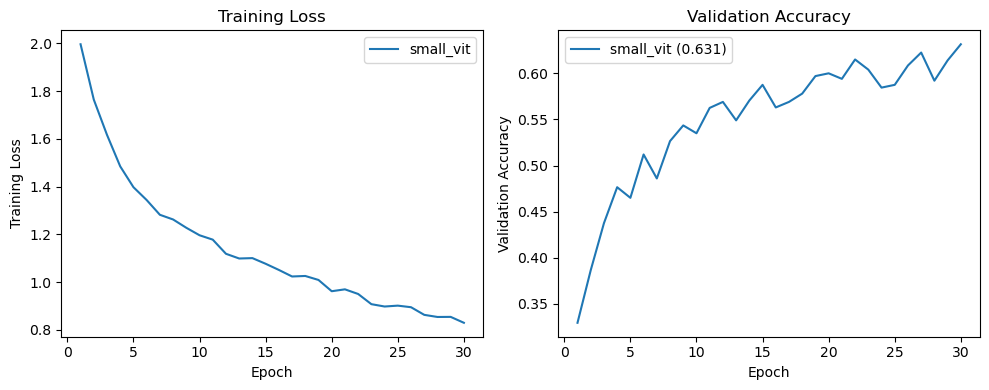

In [10]:
# Train the small ViT from scratch on Imagenette2
small_vit = SmallVisionTransformer(number_of_classes=len(class_names))
small_vit, small_vit_history = train_image_classifier(
    small_vit,
    scratch_train_loader,
    scratch_val_loader,
    model_name="small_vit",
    max_epochs=30,
    patience=5,
    lr=3e-4,
    weight_decay=5e-2,
)
plot_histories({"small_vit": small_vit_history})


## Evaluating Image Classifiers

Validation accuracy is useful during training, but confusion matrices show which classes are being confused. Imagenette2 has visually different categories, so many mistakes reveal whether the model has learned shape, texture, or background cues.

                  precision    recall  f1-score   support

           tench       0.71      0.81      0.75       181
English springer       0.58      0.73      0.65       200
 cassette player       0.57      0.57      0.57       196
       chain saw       0.55      0.38      0.45       202
          church       0.57      0.63      0.60       196
     French horn       0.71      0.62      0.66       213
   garbage truck       0.67      0.69      0.68       206
        gas pump       0.61      0.50      0.55       211
       golf ball       0.57      0.69      0.62       197
       parachute       0.78      0.74      0.76       198

        accuracy                           0.63      2000
       macro avg       0.63      0.63      0.63      2000
    weighted avg       0.63      0.63      0.63      2000



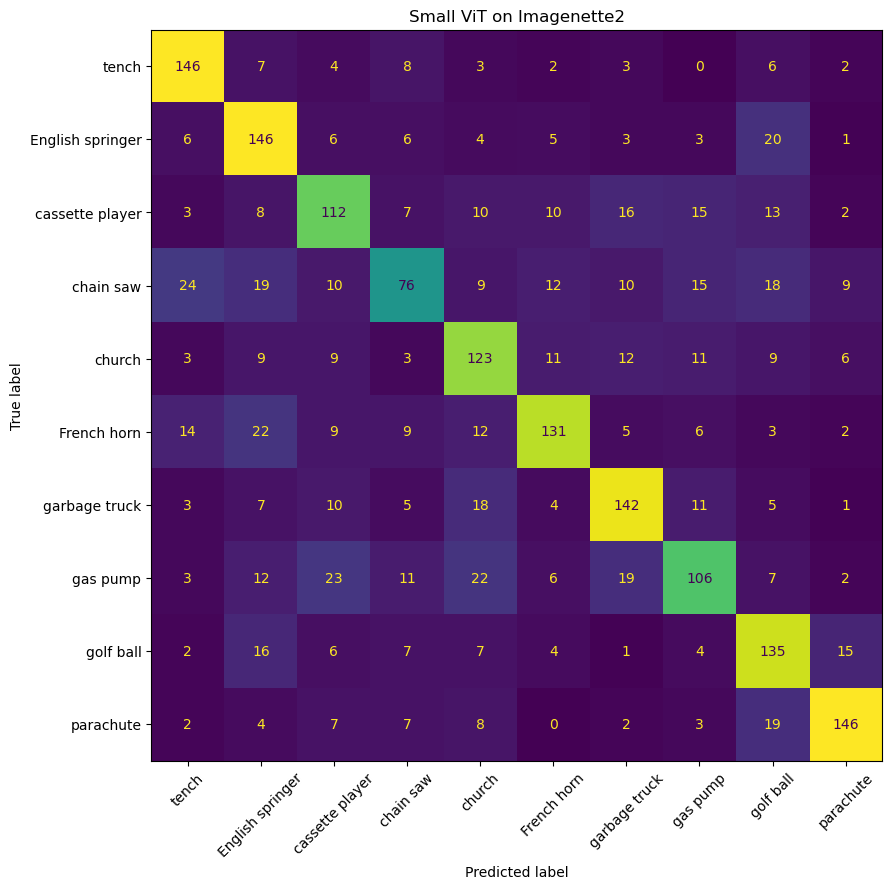

In [11]:
# Evaluation helper for Imagenette classifiers
def evaluate_image_classifier(model, data_loader, class_names, title):
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device, non_blocking=True)
            logits = model(images)
            predictions = logits.argmax(dim=1).cpu()

            all_predictions.extend(predictions.tolist())
            all_labels.extend(labels.tolist())

    print(classification_report(all_labels, all_predictions, target_names=class_names))

    matrix = confusion_matrix(all_labels, all_predictions)
    display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(9, 9))
    display.plot(ax=ax, xticks_rotation=45, colorbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


evaluate_image_classifier(small_vit, scratch_val_loader, class_names, "Small ViT on Imagenette2")


## Pretrained Vision Transformer Fine-Tuning

The original ViT result was strongest when the model was pretrained on very large datasets. On smaller datasets, a ViT trained from scratch can be data-hungry because it has less built-in locality than a CNN.

Transfer learning changes the setup. An ImageNet-pretrained ViT already has useful patch, shape, and object features. Fine-tuning adapts those features to Imagenette2.

In [12]:
# Build Imagenette loaders for pretrained ViT input size
pretrained_train_dataset = TransformSubset(base_train_dataset, train_indices, pretrained_vit_train_transforms)
pretrained_val_dataset = TransformSubset(base_val_dataset, val_indices, pretrained_vit_eval_transforms)

pretrained_train_loader = DataLoader(
    pretrained_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=IMAGENETTE_NUM_WORKERS,
    pin_memory=pin_memory,
)
pretrained_val_loader = DataLoader(
    pretrained_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=IMAGENETTE_NUM_WORKERS,
    pin_memory=pin_memory,
)

print(f"Pretrained ViT train subset: {len(pretrained_train_dataset)}")
print(f"Pretrained ViT validation subset: {len(pretrained_val_dataset)}")


Pretrained ViT train subset: 7000
Pretrained ViT validation subset: 2000


In [13]:
# Load an ImageNet-pretrained ViT and replace the classifier head
vit_weights = models.ViT_B_16_Weights.IMAGENET1K_V1
pretrained_vit = models.vit_b_16(weights=vit_weights)

in_features = pretrained_vit.heads.head.in_features
pretrained_vit.heads.head = nn.Linear(in_features, len(class_names))

for name, parameter in pretrained_vit.named_parameters():
    parameter.requires_grad = name.startswith("heads")

pretrained_vit = pretrained_vit.to(device)
print(pretrained_vit.heads)


Sequential(
  (head): Linear(in_features=768, out_features=10, bias=True)
)


In [14]:
# Train only the new classifier head first
pretrained_vit, vit_head_history = train_image_classifier(
    pretrained_vit,
    pretrained_train_loader,
    pretrained_val_loader,
    model_name="vit_head",
    max_epochs=20,
    patience=5,
    lr=1e-3,
    weight_decay=1e-4,
)


vit_head           | Epoch 001 | Train Loss: 0.1430 | Val Loss: 0.0220 | Val Acc: 0.9970 | Time: 9.2s
vit_head           | Epoch 002 | Train Loss: 0.0120 | Val Loss: 0.0140 | Val Acc: 0.9975 | Time: 9.2s
vit_head           | Epoch 003 | Train Loss: 0.0066 | Val Loss: 0.0117 | Val Acc: 0.9980 | Time: 9.2s
vit_head           | Epoch 004 | Train Loss: 0.0039 | Val Loss: 0.0106 | Val Acc: 0.9980 | Time: 9.3s
vit_head           | Epoch 005 | Train Loss: 0.0025 | Val Loss: 0.0096 | Val Acc: 0.9980 | Time: 9.3s
vit_head           | Epoch 006 | Train Loss: 0.0019 | Val Loss: 0.0095 | Val Acc: 0.9980 | Time: 9.3s
vit_head           | Epoch 007 | Train Loss: 0.0017 | Val Loss: 0.0093 | Val Acc: 0.9985 | Time: 9.3s
vit_head           | Epoch 008 | Train Loss: 0.0012 | Val Loss: 0.0092 | Val Acc: 0.9985 | Time: 9.3s
vit_head           | Epoch 009 | Train Loss: 0.0009 | Val Loss: 0.0091 | Val Acc: 0.9980 | Time: 9.3s
vit_head           | Epoch 010 | Train Loss: 0.0009 | Val Loss: 0.0091 | Val Acc: 

vit_finetune       | Epoch 001 | Train Loss: 0.0013 | Val Loss: 0.0088 | Val Acc: 0.9980 | Time: 11.1s
vit_finetune       | Epoch 002 | Train Loss: 0.0005 | Val Loss: 0.0094 | Val Acc: 0.9970 | Time: 11.1s
vit_finetune       | Epoch 003 | Train Loss: 0.0004 | Val Loss: 0.0081 | Val Acc: 0.9980 | Time: 11.1s
vit_finetune       | Epoch 004 | Train Loss: 0.0006 | Val Loss: 0.0074 | Val Acc: 0.9985 | Time: 11.1s
vit_finetune       | Epoch 005 | Train Loss: 0.0003 | Val Loss: 0.0088 | Val Acc: 0.9985 | Time: 11.2s
vit_finetune       | Epoch 006 | Train Loss: 0.0002 | Val Loss: 0.0089 | Val Acc: 0.9975 | Time: 11.1s
vit_finetune       | Epoch 007 | Train Loss: 0.0002 | Val Loss: 0.0094 | Val Acc: 0.9980 | Time: 11.2s
vit_finetune       | Epoch 008 | Train Loss: 0.0001 | Val Loss: 0.0087 | Val Acc: 0.9980 | Time: 11.1s
vit_finetune       | Epoch 009 | Train Loss: 0.0001 | Val Loss: 0.0087 | Val Acc: 0.9980 | Time: 11.2s
Early stopping vit_finetune at epoch 9


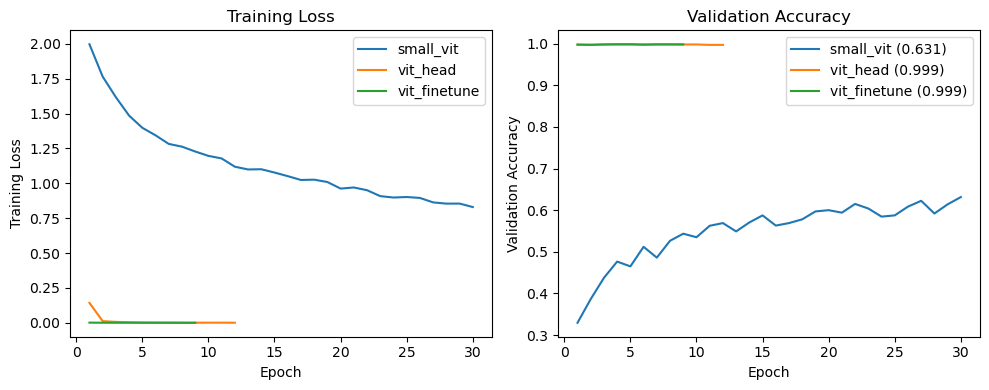

In [15]:
# Unfreeze the final encoder blocks for a short fine-tuning phase
for name, parameter in pretrained_vit.named_parameters():
    if name.startswith("encoder.layers.encoder_layer_10"):
        parameter.requires_grad = True
    if name.startswith("encoder.layers.encoder_layer_11"):
        parameter.requires_grad = True
    if name.startswith("heads"):
        parameter.requires_grad = True

pretrained_vit, vit_finetune_history = train_image_classifier(
    pretrained_vit,
    pretrained_train_loader,
    pretrained_val_loader,
    model_name="vit_finetune",
    max_epochs=20,
    patience=5,
    lr=1e-5,
    weight_decay=1e-4,
)

plot_histories({
    "small_vit": small_vit_history,
    "vit_head": vit_head_history,
    "vit_finetune": vit_finetune_history,
})


                  precision    recall  f1-score   support

           tench       1.00      1.00      1.00       181
English springer       1.00      1.00      1.00       200
 cassette player       1.00      1.00      1.00       196
       chain saw       1.00      1.00      1.00       202
          church       0.99      1.00      1.00       196
     French horn       1.00      1.00      1.00       213
   garbage truck       1.00      1.00      1.00       206
        gas pump       1.00      1.00      1.00       211
       golf ball       1.00      1.00      1.00       197
       parachute       1.00      0.99      1.00       198

        accuracy                           1.00      2000
       macro avg       1.00      1.00      1.00      2000
    weighted avg       1.00      1.00      1.00      2000



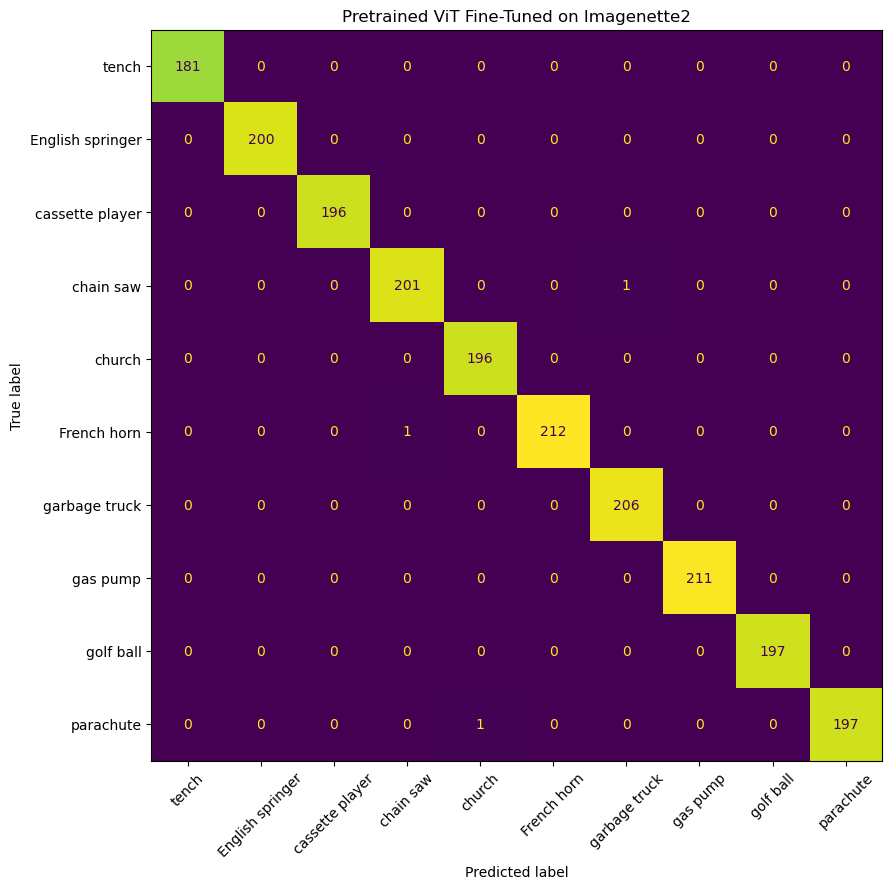

In [16]:
# Evaluate the fine-tuned pretrained ViT
evaluate_image_classifier(
    pretrained_vit,
    pretrained_val_loader,
    class_names,
    "Pretrained ViT Fine-Tuned on Imagenette2",
)


## ViT Takeaways

Vision transformers reuse transformer encoder ideas from language, but the input sequence is made from image patches instead of word or subword tokens.

The main architectural pieces are:

- patch embedding: image patches become token vectors,
- class token: a learned summary token for classification,
- position embedding: spatial order information,
- multi-head self-attention: each patch can attend to all other patches,
- MLP block: per-token nonlinear processing,
- residual connections and layer normalization: stable deep training.

The practical lesson is that ViTs are powerful but data-hungry. A small ViT trained from scratch on Imagenette2 is a useful teaching model. A pretrained ViT is the realistic modern workflow.

# Lecture 27: Guest Speaker

Guest speaker details and supporting materials will be added here.
